In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

OUTPUT_DIR = Path("../outputs")

holdout_features = pd.read_parquet(
    OUTPUT_DIR / "holdout_features.parquet"
)

graph_result = pd.read_csv(
    OUTPUT_DIR / "anomaly_graph_score.csv"
)

print("holdout_features:", holdout_features.shape)
print("graph_result:", graph_result.shape)

holdout_features: (20000, 119)
graph_result: (20000, 11)


In [2]:
# Base table for clustering
cluster_base = holdout_features.copy()

# Candidate features for persona clustering
cluster_feature_candidates = [
    # Device
    "num_imeis_90d",
    "max_customers_per_imei",
    "shared_imei_flag",
    "high_shared_imei_flag",
    "rooted_session_ratio",
    "is_rooted",
    "emulator_session_ratio",
    "is_emulator",
    "is_generic_or_clone",
    "is_feature_phone",
    "low_tier_session_ratio",
    "low_tier_device_flag",
    "tac_grey_clone_flag",
    "tac_risk_score",

    # SIM
    "sim_swap_count_90d",
    "sim_swap_count_12m",
    "days_since_last_sim_swap",
    "recent_sim_change_flag",
    "iccid_count",
    "phone_number_age_days",
    "port_in_flag",

    # Behavior
    "distinct_ip_30d",
    "distinct_country_30d",
    "datacenter_ratio_30d",
    "vpn_proxy_ratio_30d",
    "non_residential_ratio_30d",
    "home_cell_ratio_30d",
    "night_session_ratio_30d",
    "geo_velocity_alerts_30d",
    "geo_velocity_flag_30d",
    "active_days_30d",
    "total_sessions_30d",
    "avg_sessions_per_day_30d",

    # Identity
    "kyc_level_ord",
    "has_face_score",
    "has_iddoc_score",
    "face_match_score",
    "id_doc_match_score",
]

# Keep only columns that exist
cluster_feature_cols = [
    col for col in cluster_feature_candidates
    if col in cluster_base.columns
]

missing_cluster_cols = [
    col for col in cluster_feature_candidates
    if col not in cluster_base.columns
]

print("Number of clustering features:", len(cluster_feature_cols))
print("Missing candidate features:", missing_cluster_cols)

Number of clustering features: 38
Missing candidate features: []


In [3]:
X_cluster_raw = cluster_base[cluster_feature_cols].copy()

print("X_cluster_raw shape:", X_cluster_raw.shape)

X_cluster_raw.head()

X_cluster_raw shape: (20000, 38)


,num_imeis_90d,max_customers_per_imei,shared_imei_flag,high_shared_imei_flag,rooted_session_ratio,is_rooted,emulator_session_ratio,is_emulator,is_generic_or_clone,is_feature_phone,...,geo_velocity_alerts_30d,geo_velocity_flag_30d,active_days_30d,total_sessions_30d,avg_sessions_per_day_30d,kyc_level_ord,has_face_score,has_iddoc_score,face_match_score,id_doc_match_score
0,2,1,0,0,0.0,0,0.0,0,0,0,...,0.0,0.0,7.0,7.0,1.000000,1,0,1,0.000,0.896
1,1,1,0,0,0.0,0,0.0,0,0,0,...,0.0,0.0,8.0,9.0,1.125000,2,1,1,0.855,0.869
2,1,3,1,0,0.0,0,0.0,0,0,1,...,0.0,0.0,5.0,5.0,1.000000,2,1,1,0.721,0.864
3,1,1,0,0,0.0,0,0.0,0,0,0,...,0.0,0.0,6.0,7.0,1.166667,2,1,1,0.972,0.989
4,1,1,0,0,0.0,0,0.0,0,0,0,...,0.0,0.0,6.0,7.0,1.166667,2,1,1,1.000,0.985


In [4]:
missing_rate = (
    X_cluster_raw
    .isna()
    .mean()
    .sort_values(ascending=False)
)

missing_rate[missing_rate > 0]

Series([], dtype: float64)

In [5]:
binary_cols = [
    "shared_imei_flag",
    "high_shared_imei_flag",
    "is_rooted",
    "is_emulator",
    "is_generic_or_clone",
    "is_feature_phone",
    "low_tier_device_flag",
    "tac_grey_clone_flag",
    "recent_sim_change_flag",
    "port_in_flag",
    "geo_velocity_flag_30d",
    "has_face_score",
    "has_iddoc_score",
]

count_cols = [
    "num_imeis_90d",
    "max_customers_per_imei",
    "sim_swap_count_90d",
    "sim_swap_count_12m",
    "iccid_count",
    "distinct_ip_30d",
    "distinct_country_30d",
    "geo_velocity_alerts_30d",
    "active_days_30d",
    "total_sessions_30d",
    "avg_sessions_per_day_30d",
]

day_cols = [
    "days_since_last_sim_swap",
    "phone_number_age_days",
]

continuous_cols = [
    "rooted_session_ratio",
    "emulator_session_ratio",
    "low_tier_session_ratio",
    "tac_risk_score",
    "datacenter_ratio_30d",
    "vpn_proxy_ratio_30d",
    "non_residential_ratio_30d",
    "home_cell_ratio_30d",
    "night_session_ratio_30d",
    "kyc_level_ord",
    "face_match_score",
    "id_doc_match_score",
]

binary_cols = [col for col in binary_cols if col in cluster_feature_cols]
count_cols = [col for col in count_cols if col in cluster_feature_cols]
day_cols = [col for col in day_cols if col in cluster_feature_cols]
continuous_cols = [col for col in continuous_cols if col in cluster_feature_cols]

print("binary:", len(binary_cols), binary_cols)
print("count:", len(count_cols), count_cols)
print("day:", len(day_cols), day_cols)
print("continuous:", len(continuous_cols), continuous_cols)

all_typed_cols = binary_cols + count_cols + day_cols + continuous_cols

missing_typed = sorted(set(cluster_feature_cols) - set(all_typed_cols))
missing_typed

binary: 13 ['shared_imei_flag', 'high_shared_imei_flag', 'is_rooted', 'is_emulator', 'is_generic_or_clone', 'is_feature_phone', 'low_tier_device_flag', 'tac_grey_clone_flag', 'recent_sim_change_flag', 'port_in_flag', 'geo_velocity_flag_30d', 'has_face_score', 'has_iddoc_score']
count: 11 ['num_imeis_90d', 'max_customers_per_imei', 'sim_swap_count_90d', 'sim_swap_count_12m', 'iccid_count', 'distinct_ip_30d', 'distinct_country_30d', 'geo_velocity_alerts_30d', 'active_days_30d', 'total_sessions_30d', 'avg_sessions_per_day_30d']
day: 2 ['days_since_last_sim_swap', 'phone_number_age_days']
continuous: 12 ['rooted_session_ratio', 'emulator_session_ratio', 'low_tier_session_ratio', 'tac_risk_score', 'datacenter_ratio_30d', 'vpn_proxy_ratio_30d', 'non_residential_ratio_30d', 'home_cell_ratio_30d', 'night_session_ratio_30d', 'kyc_level_ord', 'face_match_score', 'id_doc_match_score']


[]

In [6]:
X_cluster_processed_parts = []

if binary_cols:
    X_binary = X_cluster_raw[binary_cols].copy()
    X_binary = X_binary.fillna(0)
    X_cluster_processed_parts.append(X_binary)

if count_cols:
    X_count = X_cluster_raw[count_cols].copy()
    
    for col in count_cols:
        X_count[col] = np.log1p(X_count[col])
    
    count_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
        ]
    )
    
    X_count_scaled = pd.DataFrame(
        count_pipeline.fit_transform(X_count),
        columns=count_cols,
        index=X_count.index,
    )
    
    X_cluster_processed_parts.append(X_count_scaled)

if day_cols:
    X_day = X_cluster_raw[day_cols].copy()
    
    for col in day_cols:
        upper = X_day[col].quantile(0.99)
        X_day[col] = X_day[col].clip(upper=upper)
        X_day[col] = np.log1p(X_day[col])
    
    day_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
        ]
    )
    
    X_day_scaled = pd.DataFrame(
        day_pipeline.fit_transform(X_day),
        columns=day_cols,
        index=X_day.index,
    )
    
    X_cluster_processed_parts.append(X_day_scaled)

if continuous_cols:
    X_cont = X_cluster_raw[continuous_cols].copy()
    
    cont_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
        ]
    )
    
    X_cont_scaled = pd.DataFrame(
        cont_pipeline.fit_transform(X_cont),
        columns=continuous_cols,
        index=X_cont.index,
    )
    
    X_cluster_processed_parts.append(X_cont_scaled)

X_cluster_df = pd.concat(X_cluster_processed_parts, axis=1)

X_cluster = X_cluster_df.values

X_cluster_df.shape

(20000, 38)

In [7]:
X_cluster_df.describe().T[
    ["mean", "std", "min", "25%", "50%", "75%", "max"]
].sort_values("max", ascending=False).head(20)

,mean,std,min,25%,50%,75%,max
avg_sessions_per_day_30d,0.502416,0.811425,-7.272541,0.000000,0.0,1.000000,9.613776
tac_risk_score,-0.343050,0.550983,-1.000000,-1.000000,0.0,0.000000,4.000000
distinct_ip_30d,-0.063919,0.810185,-3.969362,-0.550340,0.0,0.449660,2.709511
iccid_count,0.315011,0.518393,0.000000,0.000000,0.0,1.000000,2.709511
active_days_30d,-0.236315,0.765977,-4.140202,-0.715893,0.0,0.284107,2.531010
night_session_ratio_30d,0.075166,0.670864,-0.600000,-0.600000,0.0,0.400000,2.400000
sim_swap_count_12m,0.309745,0.503348,0.000000,0.000000,0.0,1.000000,2.321928
total_sessions_30d,-0.054869,0.653216,-3.310572,-0.572439,0.0,0.427561,2.296627
geo_velocity_alerts_30d,0.020644,0.124947,0.000000,0.000000,0.0,0.000000,1.609438
max_customers_per_imei,0.033829,0.153738,0.000000,0.000000,0.0,0.000000,1.504077


In [8]:
k_range = range(3, 9)

kmeans_results = []

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init=20,
    )

    labels = kmeans.fit_predict(X_cluster)

    sil = silhouette_score(
        X_cluster,
        labels,
        sample_size=min(5000, X_cluster.shape[0]),
        random_state=42,
    )

    cluster_sizes = pd.Series(labels).value_counts(normalize=True)

    kmeans_results.append(
        {
            "k": k,
            "inertia": kmeans.inertia_,
            "silhouette": sil,
            "largest_cluster_pct": cluster_sizes.max(),
            "smallest_cluster_pct": cluster_sizes.min(),
        }
    )

kmeans_eval = pd.DataFrame(kmeans_results)

kmeans_eval

,k,inertia,silhouette,largest_cluster_pct,smallest_cluster_pct
0,3,120646.664619,0.199043,0.60480,0.10240
1,4,109384.730248,0.198440,0.42935,0.10235
2,5,102434.312296,0.184551,0.29580,0.10230
3,6,97827.680114,0.177690,0.22635,0.10225
4,7,94826.317429,0.179173,0.22590,0.09070
5,8,91870.763739,0.186751,0.19560,0.05270


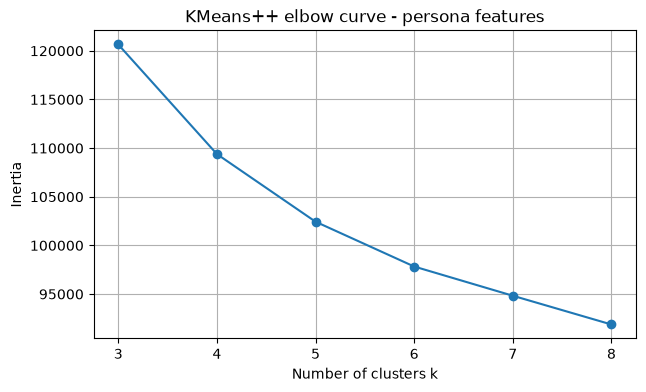

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(kmeans_eval["k"], kmeans_eval["inertia"], marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.title("KMeans++ elbow curve - persona features")
plt.grid(True)
plt.show()

In [10]:
best_k = 4

kmeans_final = KMeans(
    n_clusters=best_k,
    init="k-means++",
    random_state=42,
    n_init=20,
)

cluster_labels = kmeans_final.fit_predict(X_cluster)

cluster_result = pd.DataFrame({
    "CustomerID": holdout_features["CustomerID"],
    "cluster_id": cluster_labels,
})

cluster_result.head()

,CustomerID,cluster_id
0,3000006,2
1,3000018,3
2,3000034,3
3,3000070,2
4,3000074,2


In [11]:
cluster_size = (
    cluster_result["cluster_id"]
    .value_counts()
    .sort_index()
    .rename("size")
    .to_frame()
)

cluster_size["size_pct"] = cluster_size["size"] / cluster_size["size"].sum()

cluster_size

,size,size_pct
cluster_id,,
0,4788,0.23940
1,2047,0.10235
2,8587,0.42935
3,4578,0.22890


In [12]:
# Merge graph/anomaly để profile, không dùng để fit

graph_profile_cols = [
    "CustomerID",
    "anomaly_score",
    "graph_adjusted_anomaly_score",
    "neighbor_count",
    "neighbor_anomaly_max",
    "neighbor_anomaly_mean",
]

graph_profile_cols = [
    col for col in graph_profile_cols
    if col in graph_result.columns
]

cluster_result = cluster_result.merge(
    graph_result[graph_profile_cols],
    on="CustomerID",
    how="left",
)

cluster_result.head()

,CustomerID,cluster_id,anomaly_score,graph_adjusted_anomaly_score,neighbor_count,neighbor_anomaly_max,neighbor_anomaly_mean
0,3000006,2,0.949450,0.919423,0,0.000000,0.000000
1,3000018,3,0.671175,0.662608,0,0.000000,0.000000
2,3000034,3,0.985205,0.991600,2,0.969225,0.763455
3,3000070,2,0.948260,0.918432,0,0.000000,0.000000
4,3000074,2,0.593465,0.587638,0,0.000000,0.000000


In [13]:
cluster_profile_df = holdout_features.merge(
    cluster_result,
    on="CustomerID",
    how="left",
)

cluster_profile_df.shape

(20000, 125)

In [14]:
cluster_summary = (
    cluster_profile_df
    .groupby("cluster_id")
    .agg(
        size=("CustomerID", "count"),
        anomaly_mean=("anomaly_score", "mean"),
        graph_anomaly_mean=("graph_adjusted_anomaly_score", "mean"),
        anomaly_p90=("graph_adjusted_anomaly_score", lambda x: x.quantile(0.90)),
        neighbor_count_mean=("neighbor_count", "mean"),
        neighbor_anomaly_max_mean=("neighbor_anomaly_max", "mean"),
    )
    .reset_index()
)

cluster_summary["size_pct"] = (
    cluster_summary["size"] / cluster_summary["size"].sum()
)

cluster_summary.sort_values("graph_anomaly_mean", ascending=False)

,cluster_id,size,anomaly_mean,graph_anomaly_mean,anomaly_p90,neighbor_count_mean,neighbor_anomaly_max_mean,size_pct
1,1,2047,0.621299,0.617494,0.911493,0.505129,0.110321,0.10235
3,3,4578,0.553620,0.551094,0.885380,0.274356,0.075848,0.22890
0,0,4788,0.467314,0.467744,0.836366,0.224728,0.063455,0.23940
2,2,8587,0.460781,0.462795,0.844105,0.327472,0.086670,0.42935


In [15]:
profile_cols = cluster_feature_cols.copy()

cluster_feature_profile = (
    cluster_profile_df
    .groupby("cluster_id")[profile_cols]
    .mean()
    .reset_index()
)

cluster_feature_profile

,cluster_id,num_imeis_90d,max_customers_per_imei,shared_imei_flag,high_shared_imei_flag,rooted_session_ratio,is_rooted,emulator_session_ratio,is_emulator,is_generic_or_clone,...,geo_velocity_alerts_30d,geo_velocity_flag_30d,active_days_30d,total_sessions_30d,avg_sessions_per_day_30d,kyc_level_ord,has_face_score,has_iddoc_score,face_match_score,id_doc_match_score
0,0,1.082498,1.083124,0.046784,0.005013,0.016708,0.016708,0.000627,0.000627,0.009190,...,0.007519,0.007519,3.321220,3.487051,1.049271,1.600042,0.600042,1.000000,0.542760,0.924117
1,1,1.090865,1.206155,0.079140,0.025892,0.040059,0.040059,0.005688,0.005862,0.006839,...,0.031754,0.028823,5.576453,6.156815,1.100743,0.016610,0.003908,0.012702,0.003493,0.004659
2,2,1.077443,1.096774,0.053453,0.006172,0.023873,0.023873,0.001237,0.001281,0.008618,...,0.040293,0.034005,6.742867,7.560033,1.129415,1.599511,0.599511,1.000000,0.542519,0.924868
3,3,1.092398,1.083006,0.046745,0.004369,0.022499,0.022499,0.000218,0.000218,0.007864,...,0.039755,0.036260,6.056356,6.730013,1.116592,1.608126,0.608126,1.000000,0.550869,0.925792


In [16]:
global_mean = cluster_profile_df[profile_cols].mean()

cluster_lift = (
    cluster_profile_df
    .groupby("cluster_id")[profile_cols]
    .mean()
    .div(global_mean.replace(0, np.nan))
)

cluster_lift = cluster_lift.replace([np.inf, -np.inf], np.nan)

cluster_lift

,num_imeis_90d,max_customers_per_imei,shared_imei_flag,high_shared_imei_flag,rooted_session_ratio,is_rooted,emulator_session_ratio,is_emulator,is_generic_or_clone,is_feature_phone,...,geo_velocity_alerts_30d,geo_velocity_flag_30d,active_days_30d,total_sessions_30d,avg_sessions_per_day_30d,kyc_level_ord,has_face_score,has_iddoc_score,face_match_score,id_doc_match_score
cluster_id,,,,,,,,,,,,,,,,,,,,,
0,0.999121,0.983273,0.883543,0.668338,0.710997,0.710997,0.477099,0.464123,1.094005,0.939905,...,0.239071,0.271928,0.588118,0.557808,0.950118,1.111449,1.109853,1.112409,1.109215,1.112434
1,1.006844,1.094962,1.494621,3.452206,1.704622,1.704622,4.330952,4.342398,0.814200,0.950407,...,1.009659,1.042411,0.987472,0.984878,0.996726,0.011538,0.007229,0.014129,0.007138,0.005608
2,0.994455,0.995664,1.009498,0.822949,1.015885,1.015885,0.941975,0.948893,1.025914,1.038199,...,1.281191,1.229833,1.194020,1.209344,1.022688,1.111080,1.108871,1.112409,1.108723,1.113338
3,1.008259,0.983165,0.882820,0.582496,0.957400,0.957400,0.166328,0.161804,0.936154,1.013375,...,1.264081,1.311406,1.072453,1.076570,1.011077,1.117064,1.124805,1.112409,1.125789,1.114450


In [17]:
for cid in sorted(cluster_lift.index):
    print(f"\nCluster {cid}")
    display(
        cluster_lift
        .loc[cid]
        .sort_values(ascending=False)
        .head(12)
        .to_frame("lift")
    )


Cluster 0


,lift
days_since_last_sim_swap,1.218735
id_doc_match_score,1.112434
has_iddoc_score,1.112409
kyc_level_ord,1.111449
has_face_score,1.109853
face_match_score,1.109215
is_generic_or_clone,1.094005
phone_number_age_days,1.013109
num_imeis_90d,0.999121
night_session_ratio_30d,0.997322



Cluster 1


,lift
is_emulator,4.342398
emulator_session_ratio,4.330952
high_shared_imei_flag,3.452206
tac_grey_clone_flag,2.160761
rooted_session_ratio,1.704622
is_rooted,1.704622
vpn_proxy_ratio_30d,1.688494
non_residential_ratio_30d,1.584690
datacenter_ratio_30d,1.513951
shared_imei_flag,1.494621



Cluster 2


,lift
days_since_last_sim_swap,1.391007
geo_velocity_alerts_30d,1.281191
geo_velocity_flag_30d,1.229833
total_sessions_30d,1.209344
active_days_30d,1.194020
distinct_ip_30d,1.176611
id_doc_match_score,1.113338
has_iddoc_score,1.112409
kyc_level_ord,1.111080
has_face_score,1.108871



Cluster 3


,lift
recent_sim_change_flag,3.701740
sim_swap_count_90d,3.674707
sim_swap_count_12m,3.548919
iccid_count,1.629552
geo_velocity_flag_30d,1.311406
geo_velocity_alerts_30d,1.264081
face_match_score,1.125789
has_face_score,1.124805
kyc_level_ord,1.117064
id_doc_match_score,1.114450
